In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [4]:
subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [9]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [10]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [12]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

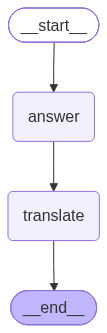

In [13]:
graph = parent_builder.compile()

graph

In [14]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how nature works at the smallest scales—typically atomic and sub‑atomic particles such as electrons, photons, atoms, and molecules.  \n\n### Why classical physics isn’t enough\n- **Classical physics** (Newtonian mechanics, electromagnetism, thermodynamics) treats objects as having definite positions, velocities, and energies that can be measured precisely at any moment.\n- When experiments probed the behavior of particles at nanometer and picometer scales, they revealed phenomena that could not be explained by classical laws (e.g., black‑body radiation, photoelectric effect, atomic spectra).\n\n### Core Concepts of Quantum Physics\n\n| Concept | What It Means | Everyday Analogy (if any) |\n|---------|---------------|--------------------------|\n| **Wave‑Particle Duality** | Particles such as electrons and photons exhibit b